In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers torch torchaudio requests

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
import os
import evaluate
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, Audio, load_from_disk
from transformers import (
    ASTFeatureExtractor,
    ASTForAudioClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
# 1. SETUP PATHS (Adjust 'dataset_path' to where your 'audio' folder is)
dataset_path = "/content/drive/MyDrive/Urban8KAudioFiles"
csv_path = "/content/drive/MyDrive/Urban8KAudioFiles/UrbanSound8K.csv"


In [ ]:
train_save_path = "/content/drive/MyDrive/Urban8KAudioFiles/processed_train"
test_save_path = "/content/drive/MyDrive/Urban8KAudioFiles/processed_test"

In [ ]:
encoded_train = load_from_disk(train_save_path)
encoded_test = load_from_disk(test_save_path)

In [ ]:
from datasets import load_from_disk
import torch

# 1. Load the processed datasets from your Drive
try:
    train_verify = load_from_disk("/content/drive/MyDrive/Urban8KAudioFiles/processed_train")
    test_verify = load_from_disk("/content/drive/MyDrive/Urban8KAudioFiles/processed_test")
    print(f"✅ Success! Loaded {len(train_verify)} training samples and {len(test_verify)} test samples.")
except Exception as e:
    print(f"❌ Error loading files: {e}")

# 2. Inspect a random sample (e.g., sample #100)
sample = train_verify[100]

print("\n--- Sample Verification ---")
print(f"Keys present in dataset: {sample.keys()}")

# Check the Spectrogram shape
# For AST, this should typically be [1, 1024, 128]
input_values = torch.tensor(sample['input_values'])
print(f"Spectrogram shape: {input_values.shape}")

# Check the Label
print(f"Label ID: {sample['labels']}")

# 3. Quick Data Validation
if input_values.abs().sum() > 0:
    print("✅ Data Integrity: Spectrogram contains non-zero numerical data.")
else:
    print("⚠️ Warning: Spectrogram appears to be empty (all zeros).")

✅ Success! Loaded 7895 training samples and 837 test samples.

--- Sample Verification ---
Keys present in dataset: dict_keys(['input_values', 'labels'])
Spectrogram shape: torch.Size([1024, 128])
Label ID: 8
✅ Data Integrity: Spectrogram contains non-zero numerical data.


In [ ]:
model_id = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = ASTFeatureExtractor.from_pretrained(model_id)
def preprocess_function(batch):
    # This assumes cast_column worked and we have a list of dicts with 'array'
    audio_arrays = [x["array"] for x in batch["file_path"]]

    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=16000,
        padding="max_length",
        max_length=1024,
        return_tensors="pt"
    )
    inputs["labels"] = batch["label"]
    return inputs

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [ ]:
model = ASTForAudioClassification.from_pretrained(
    model_id,
    num_labels=10,
    ignore_mismatched_sizes=True
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
# 7. TRAINING ARGUMENTS
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Urban8KAudioFiles/ast_urban_results",
    eval_strategy="epoch",       # CHANGED from evaluation_strategy
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=5,
    optim="adamw_torch",
    warmup_steps=500,
    fp16=False,                  # Set to False because you are on XLA/TPU
    bf16=True,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"             # Prevents errors if WandB isn't installed
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train,
    eval_dataset=encoded_test,
    compute_metrics=compute_metrics,
)



In [ ]:
# 8. START TRAINING
trainer.train()

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.490000,0.641831,0.861009
2,0.223750,0.375538,0.897909
3,0.080625,0.335815,0.907749
4,0.035781,0.375891,0.907749
5,0.024063,0.368788,0.907749


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1235, training_loss=0.4558103491902834, metrics={'train_runtime': 3880.2799, 'train_samples_per_second': 10.175, 'train_steps_per_second': 0.318, 'total_flos': 2.675918589984768e+18, 'train_loss': 0.4558103491902834, 'epoch': 5.0})

In [ ]:
# Define the saving path on your Google Drive
save_directory = "/content/drive/MyDrive/Urban8KAudioFiles/finetuned_ast_model"

# 1. Save the model
trainer.save_model(save_directory)

# 2. Save the feature extractor (very important for preprocessing during testing)
feature_extractor.save_pretrained(save_directory)

print(f"✅ Model and feature extractor saved to {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and feature extractor saved to /content/drive/MyDrive/Urban8KAudioFiles/finetuned_ast_model


Generating predictions on the test set...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



--- Classification Report ---
                  precision    recall  f1-score   support

 air_conditioner       0.87      0.88      0.88       100
        car_horn       0.93      0.93      0.93        27
children_playing       0.87      0.99      0.93        98
        dog_bark       0.79      0.94      0.86        94
        drilling       0.95      0.84      0.89        99
   engine_idling       0.96      0.90      0.93        89
        gun_shot       1.00      1.00      1.00        30
      jackhammer       0.99      1.00      0.99        94
           siren       0.98      0.72      0.83        82
    street_music       0.87      0.94      0.90       100

        accuracy                           0.91       813
       macro avg       0.92      0.91      0.91       813
    weighted avg       0.91      0.91      0.91       813



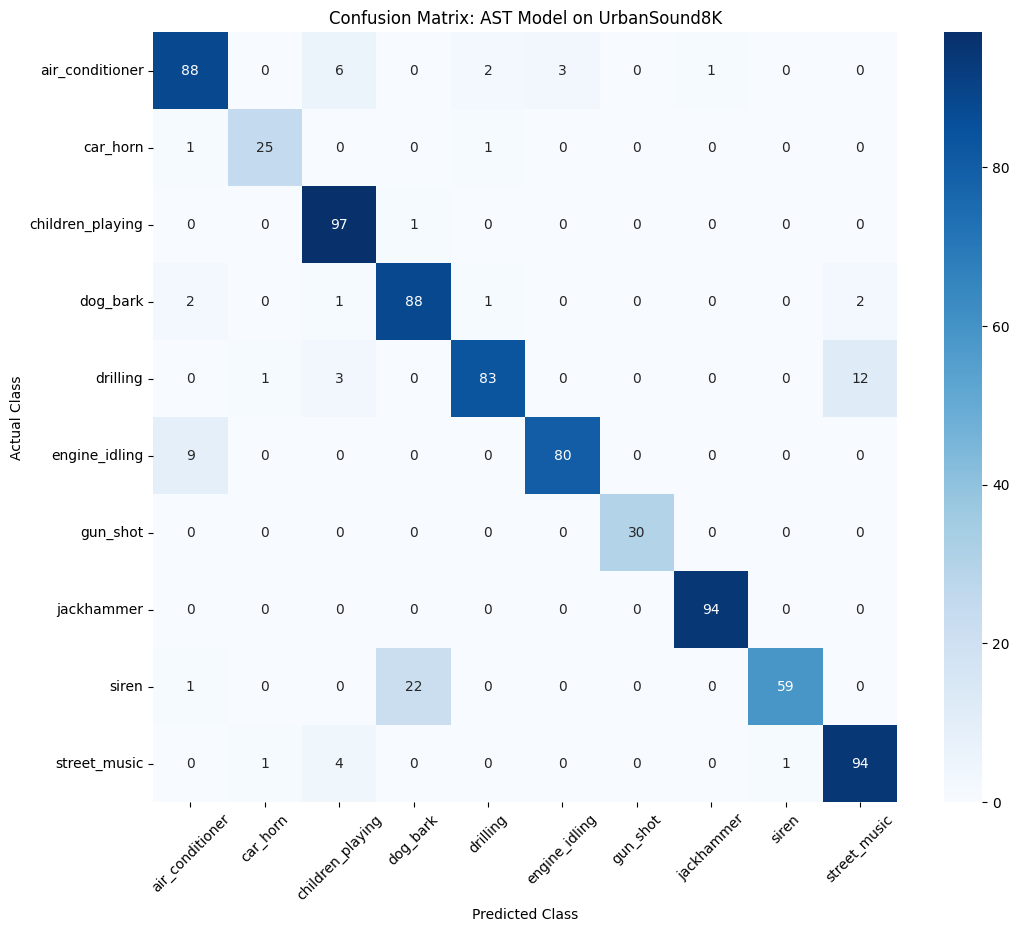

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get Predictions
print("Generating predictions on the test set...")
output = trainer.predict(encoded_test) # Replace with your test dataset variable
y_pred = np.argmax(output.predictions, axis=1)
y_true = output.label_ids

# 2. Define the UrbanSound8K Class Names
class_names = [
    "air_conditioner", "car_horn", "children_playing", "dog_bark",
    "drilling", "engine_idling", "gun_shot", "jackhammer", "siren", "street_music"
]

# 3. Print Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Plot Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix: AST Model on UrbanSound8K")
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import json

# Path to the trainer state in your output directory
state_path = "/content/drive/MyDrive/Urban8KAudioFiles/ast_urban_results/checkpoint-1235/trainer_state.json"

with open(state_path, 'r') as f:
    state = json.load(f)

best_ckpt = state.get("best_model_checkpoint", "Not Found")
best_metric = state.get("best_metric", "Not Found")

print(f"🏆 The Best Model is from: {best_ckpt}")
print(f"📊 The Best Metric value was: {best_metric}")

🏆 The Best Model is from: /content/drive/MyDrive/Urban8KAudioFiles//ast_urban_results/checkpoint-741
📊 The Best Metric value was: 0.9077490774907749


In [ ]:
from transformers import AutoConfig, AutoModelForAudioClassification

model_path = "/content/drive/MyDrive/Urban8KAudioFiles/finetuned_ast_model"

# Define your specific UrbanSound8K mapping
labels = [
    "air_conditioner", "car_horn", "children_playing", "dog_bark",
    "drilling", "engine_idling", "gun_shot", "jackhammer", "siren", "street_music"
]

id2label = {str(i): label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

# Load and update the config
config = AutoConfig.from_pretrained(model_path)
config.id2label = id2label
config.label2id = label2id

# Save the updated config back to your folder
config.save_pretrained(model_path)
print("Config updated with human-readable labels!")

Config updated with human-readable labels!


# Testing Finetuned model

In [5]:
from transformers import pipeline
import torch

# Path to your saved model folder
model_path = "/content/drive/MyDrive/Urban8KAudioFiles/finetuned_ast_model/"

# Initialize the audio classification pipeline
classifier = pipeline("audio-classification", model=model_path, device=0 if torch.cuda.is_available() else -1)

# Test an audio file (can be a local path or a URL)
audio_file = "/content/test_sound.wav"
results = classifier(audio_file)

# Mapping dictionary to fix the "LABEL_X" issue visually
class_map = {
    "LABEL_0": "air_conditioner", "LABEL_1": "car_horn", "LABEL_2": "children_playing",
    "LABEL_3": "dog_bark", "LABEL_4": "drilling", "LABEL_5": "engine_idling",
    "LABEL_6": "gun_shot", "LABEL_7": "jackhammer", "LABEL_8": "siren", "LABEL_9": "street_music"
}

print("--- Prediction Results ---")
for res in results:
    readable_label = class_map.get(res['label'], res['label'])
    print(f"{readable_label}: {round(res['score'], 4)}")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/audio_spectrogram_transformer/feature_extraction_audio_spectrogram_transformer.py:115: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  waveform = torch.from_numpy(waveform).unsqueeze(0)


--- Prediction Results ---
air_conditioner: 0.981
engine_idling: 0.0092
children_playing: 0.003
street_music: 0.0025
jackhammer: 0.0018
gun_shot: 0.0014
dog_bark: 0.0006
siren: 0.0002
drilling: 0.0002
car_horn: 0.0001


# Testing Quantized Model

In [4]:
import torch
import torchaudio
from transformers import ASTFeatureExtractor, AutoModelForAudioClassification

# 1. Paths
model_dir = "/content/drive/MyDrive/Urban8KAudioFiles/finetuned_ast_model"
quantized_model_path = f"{model_dir}/ast_model_int8_v2.pth"
test_audio_path = "test_sound.wav" # Replace with your file

# 2. Reconstruct the Quantized Model Architecture
# We must load the base model first to get the structure
model = AutoModelForAudioClassification.from_pretrained(model_dir)
model.to('cpu')

# Apply the quantization configuration to match the saved state
model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
model_prepared = torch.quantization.prepare(model)
model_int8 = torch.quantization.convert(model_prepared)

# Now load the saved INT8 weights
model_int8.load_state_dict(torch.load(quantized_model_path))
model_int8.eval()

# 3. Process the Audio File
feature_extractor = ASTFeatureExtractor.from_pretrained(model_dir)

# Load and resample to 16kHz
audio, sr = torchaudio.load(test_audio_path)
if sr != 16000:
    resampler = torchaudio.transforms.Resample(sr, 16000)
    audio = resampler(audio)

# Convert to Mel Spectrogram patches
inputs = feature_extractor(audio.squeeze().numpy(), sampling_rate=16000, return_tensors="pt")

# 4. Run Inference on CPU
with torch.no_grad():
    # Pass the 'input_values' to the quantized model
    outputs = model_int8(inputs['input_values'])
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()

# 5. Map to Class Name
# Use your id2label mapping from the config
labels = model.config.id2label
print(f"Prediction: {labels.get(str(prediction), f'Label_{prediction}')}")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

/tmp/ipykernel_1094/2973953986.py:17: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = torch.quantization.prepare(model)
/tmp/ipykernel_1094/2973953986.py:18: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quanti

NotImplementedError: Could not run 'quantized::conv2d.new' with arguments from the 'CPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'quantized::conv2d.new' is only available for these backends: [Meta, QuantizedCPU, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradXLA, AutogradMPS, AutogradXPU, AutogradHPU, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradMeta, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Batched, VmapMode, FuncTorchGradWrapper, PythonTLSSnapshot, FuncTorchDynamicLayerFrontMode, PreDispatch,